In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("✅ Все библиотеки загружены!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

✅ Все библиотеки загружены!
pandas: 3.0.2
numpy: 2.4.4


In [2]:
# ── BLOCK 2: Creating the dataset ──────────────────────────
np.random.seed(42)

clients = pd.DataFrame([
    {"client_id": 1, "name": "Romantic",  "industry": "Retail / Flowers",     "city": "Almaty",  "contract_start": "2023-03-01"},
    {"client_id": 2, "name": "Biosfera",  "industry": "Healthcare / Pharmacy", "city": "Almaty",  "contract_start": "2023-01-15"},
    {"client_id": 3, "name": "Jetour",    "industry": "Automotive",            "city": "Almaty",  "contract_start": "2023-06-10"},
    {"client_id": 4, "name": "Kinetik",   "industry": "Healthcare / Sports",   "city": "Astana",  "contract_start": "2023-09-01"},
])
clients["contract_start"] = pd.to_datetime(clients["contract_start"])

campaign_types = ["SMM", "Targeted Ads", "SEO", "Content Marketing", "Email Marketing", "Influencer"]

rows = []
cid = 1
for _, client in clients.iterrows():
    for i in range(np.random.randint(8, 16)):
        start = client["contract_start"] + timedelta(days=np.random.randint(0, 300))
        end   = start + timedelta(days=np.random.randint(14, 60))
        budget_ranges = {
            "Romantic": [30000, 50000, 80000, 100000],
            "Biosfera": [80000, 120000, 200000, 350000],
            "Kinetik":  [100000, 150000, 200000, 300000],
            "Jetour":   [200000, 350000, 500000, 800000],
        }
        budget = np.random.choice(budget_ranges[client["name"]])
        spend  = round(budget * np.random.uniform(0.75, 1.0))
        impressions = int(spend * np.random.uniform(0.4, 1.0))       # CPM ~1000-2500 KZT
        clicks      = int(impressions * np.random.uniform(0.01, 0.03)) # CTR ~1-3%
        conversions = int(clicks * np.random.uniform(0.02, 0.08))      # CVR ~2-8%
        revenue     = round(conversions * np.random.uniform(3000, 10000)) # realistic ROAS
        rows.append({
            "campaign_id": cid, "client_id": client["client_id"],
            "client_name": client["name"],
            "campaign_type": np.random.choice(campaign_types),
            "start_date": start, "end_date": end,
            "budget_kzt": budget, "spend_kzt": spend,
            "impressions": impressions, "clicks": clicks,
            "conversions": conversions, "revenue_kzt": revenue,
        })
        cid += 1

df = pd.DataFrame(rows)
df["CTR"] = (df["clicks"] / df["impressions"] * 100).round(2)
df["CVR"] = (df["conversions"] / df["clicks"].replace(0,1) * 100).round(2)
df["ROI"] = ((df["revenue_kzt"] - df["spend_kzt"]) / df["spend_kzt"] * 100).round(1)
df["CPC"] = (df["spend_kzt"] / df["clicks"].replace(0,1)).round(0)

print(f"✅ Dataset created: {len(df)} campaigns")
print(f"Total spend: {df['spend_kzt'].sum()/1_000_000:.2f}M KZT")
df.head()

✅ Dataset created: 45 campaigns
Total spend: 8.58M KZT


,campaign_id,client_id,client_name,campaign_type,start_date,end_date,budget_kzt,spend_kzt,impressions,clicks,conversions,revenue_kzt,CTR,CVR,ROI,CPC
0,1,1,Romantic,Content Marketing,2023-11-26,2024-01-21,100000,89966,44408,582,13,117822,1.31,2.23,31.0,155.0
1,2,1,Romantic,SMM,2023-07-30,2023-08-15,50000,38205,31832,915,18,179019,2.87,1.97,368.6,42.0
2,3,1,Romantic,Influencer,2023-03-22,2023-05-18,30000,24684,18935,242,9,50081,1.28,3.72,102.9,102.0
3,4,1,Romantic,Targeted Ads,2023-08-22,2023-10-18,80000,79665,54176,1473,89,547661,2.72,6.04,587.5,54.0
4,5,1,Romantic,Content Marketing,2023-05-28,2023-06-24,50000,42318,17332,253,8,62263,1.46,3.16,47.1,167.0


In [3]:
# ── BLOCK 3: SQL Analysis ──────────────────────────────────
import sqlite3

conn = sqlite3.connect("welon_agency.db")
df.to_sql("campaigns", conn, if_exists="replace", index=False)
clients.to_sql("clients", conn, if_exists="replace", index=False)

# Query 1: Client performance summary
q1 = pd.read_sql_query("""
    SELECT 
        client_name,
        COUNT(campaign_id)          AS total_campaigns,
        ROUND(SUM(spend_kzt)/1000)  AS total_spend_kKZT,
        ROUND(AVG(CTR), 2)          AS avg_ctr,
        ROUND(AVG(ROI), 0)          AS avg_roi_pct,
        SUM(conversions)            AS total_conversions
    FROM campaigns
    GROUP BY client_name
    ORDER BY total_spend_kKZT DESC
""", conn)

# Query 2: Best performing campaign types
q2 = pd.read_sql_query("""
    SELECT 
        campaign_type,
        COUNT(*)                AS total_campaigns,
        ROUND(AVG(CTR), 2)     AS avg_ctr,
        ROUND(AVG(CVR), 2)     AS avg_cvr,
        ROUND(AVG(ROI), 0)     AS avg_roi,
        SUM(conversions)       AS total_conversions
    FROM campaigns
    GROUP BY campaign_type
    ORDER BY avg_roi DESC
""", conn)

conn.close()

print("=== Query 1: Client Performance ===")
print(q1.to_string(index=False))
print("\n=== Query 2: Best Campaign Types ===")
print(q2.to_string(index=False))

=== Query 1: Client Performance ===
client_name  total_campaigns  total_spend_kKZT  avg_ctr  avg_roi_pct  total_conversions
     Jetour                9            3838.0     2.31        523.0               3825
   Biosfera               13            2376.0     2.13        313.0               1905
    Kinetik                9            1649.0     1.72        192.0                918
   Romantic               14             720.0     2.07        345.0                491

=== Query 2: Best Campaign Types ===
    campaign_type  total_campaigns  avg_ctr  avg_cvr  avg_roi  total_conversions
  Email Marketing                4     2.08     5.84    517.0                944
              SEO               10     1.97     4.76    391.0               1137
              SMM                9     1.91     5.12    361.0                843
     Targeted Ads                6     2.47     5.33    314.0               1561
Content Marketing                9     1.92     5.23    278.0               1847


In [4]:
# ── BLOCK 4: RFM Segmentation ─────────────────────────────
snapshot_date = df["end_date"].max() + timedelta(days=1)

rfm = df.groupby("client_name").agg(
    Recency  =("end_date",    lambda x: (snapshot_date - x.max()).days),
    Frequency=("campaign_id", "count"),
    Monetary =("spend_kzt",   "sum")
).reset_index()

# Score each client (1-4)
rfm["R_score"] = rfm["Recency"].rank(ascending=True).astype(int)
rfm["F_score"] = rfm["Frequency"].rank(ascending=False).astype(int)
rfm["M_score"] = rfm["Monetary"].rank(ascending=False).astype(int)
rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# FIX: with 4 clients the weakest tier can tie. Recency (dormancy) is the
# decisive churn signal, so a client in the weakest tier that has been
# dormant for 200+ days is flagged At Risk; an active small client is Potential.
def assign_segment(row):
    s = row["RFM_Score"]
    if s <= 5:   return "🏆 Champion"
    elif s <= 6: return "💚 Loyal"
    elif s <= 7: return "⚠️ Potential"
    else:        # weakest tier
        return "🔴 At Risk" if row["Recency"] >= 200 else "⚠️ Potential"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
rfm["Monetary_M"] = (rfm["Monetary"] / 1_000_000).round(2)

print("=== RFM Segmentation Results ===\n")
print(rfm[["client_name","Recency","Frequency","Monetary_M","RFM_Score","Segment"]].to_string(index=False))
print("\n📊 Interpretation:")
print("Recency  = days since last campaign (lower = better)")
print("Frequency = number of campaigns")
print("Monetary  = total spend in M KZT")

=== RFM Segmentation Results ===

client_name  Recency  Frequency  Monetary_M  RFM_Score      Segment
   Biosfera      243         13        2.38          8    🔴 At Risk
     Jetour       85          9        3.84          6      💚 Loyal
    Kinetik        1          9        1.65          7 ⚠️ Potential
   Romantic      182         14        0.72          8 ⚠️ Potential

📊 Interpretation:
Recency  = days since last campaign (lower = better)
Frequency = number of campaigns
Monetary  = total spend in M KZT


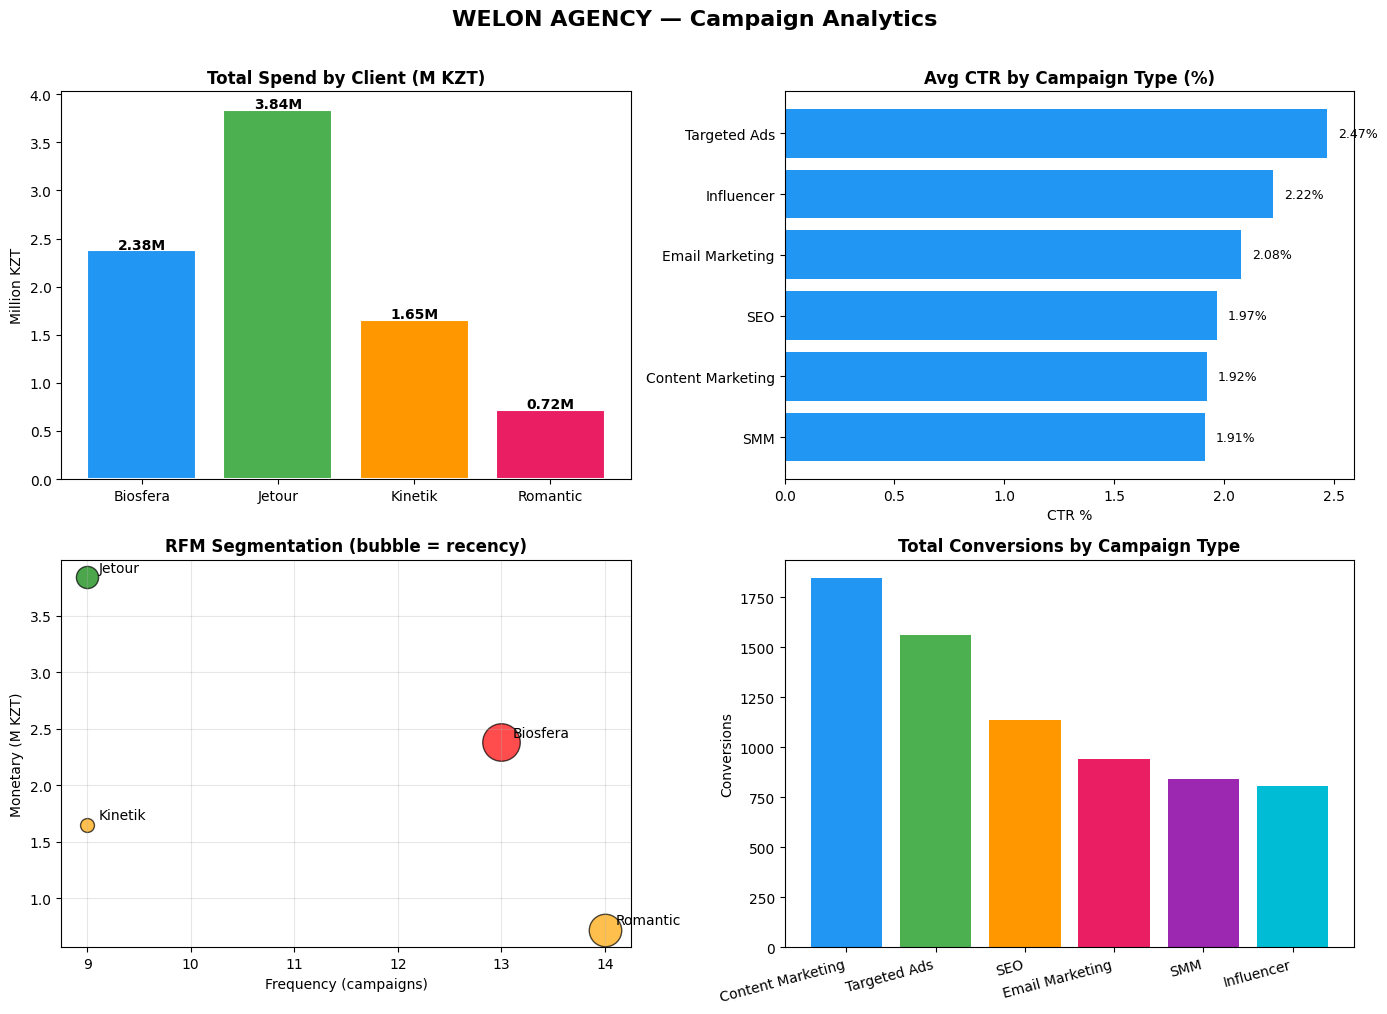

✅ Dashboard saved as welon_dashboard.png


In [5]:
# ── BLOCK 5: Visualizations ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("WELON AGENCY — Campaign Analytics", fontsize=16, fontweight="bold", y=1.01)

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

# Chart 1: Total Spend by Client
ax1 = axes[0, 0]
spend = df.groupby("client_name")["spend_kzt"].sum() / 1_000_000
bars = ax1.bar(spend.index, spend.values, color=colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Total Spend by Client (M KZT)", fontweight="bold")
ax1.set_ylabel("Million KZT")
for bar, val in zip(bars, spend.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, 
             f"{val:.2f}M", ha="center", fontsize=10, fontweight="bold")

# Chart 2: Avg CTR by Campaign Type
ax2 = axes[0, 1]
ctr = df.groupby("campaign_type")["CTR"].mean().sort_values(ascending=True)
ax2.barh(ctr.index, ctr.values, color="#2196F3")
ax2.set_title("Avg CTR by Campaign Type (%)", fontweight="bold")
ax2.set_xlabel("CTR %")
for i, val in enumerate(ctr.values):
    ax2.text(val+0.05, i, f"{val:.2f}%", va="center", fontsize=9)

# Chart 3: RFM Bubble Chart
ax3 = axes[1, 0]
seg_colors = {"🏆 Champion":"gold","💚 Loyal":"green","⚠️ Potential":"orange","🔴 At Risk":"red"}
for _, row in rfm.iterrows():
    c = seg_colors.get(row["Segment"], "gray")
    ax3.scatter(row["Frequency"], row["Monetary_M"], 
                s=max(row["Recency"]*3, 100), color=c, alpha=0.7, edgecolors="black")
    ax3.annotate(row["client_name"], (row["Frequency"], row["Monetary_M"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)
ax3.set_title("RFM Segmentation (bubble = recency)", fontweight="bold")
ax3.set_xlabel("Frequency (campaigns)")
ax3.set_ylabel("Monetary (M KZT)")
ax3.grid(alpha=0.3)

# Chart 4: Conversions by Campaign Type
ax4 = axes[1, 1]
conv = df.groupby("campaign_type")["conversions"].sum().sort_values(ascending=False)
ax4.bar(conv.index, conv.values, color=["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0","#00BCD4"])
ax4.set_title("Total Conversions by Campaign Type", fontweight="bold")
ax4.set_ylabel("Conversions")
ax4.set_xticks(range(len(conv)))            # FIX: set ticks before labels
ax4.set_xticklabels(conv.index, rotation=15, ha="right")

plt.tight_layout()
plt.savefig("welon_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved as welon_dashboard.png")

In [6]:
# ── BLOCK 6: ML Model — Churn Prediction ──────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Prepare features from RFM
X = rfm[["Recency", "Frequency", "Monetary_M"]].copy()

# Label: At Risk = 1 (churn), others = 0
rfm["Churn_Risk"] = (rfm["Segment"] == "🔴 At Risk").astype(int)
y = rfm["Churn_Risk"]

# Since we have small dataset — use all data for demo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

rfm["Churn_Probability"] = model.predict_proba(X_scaled)[:, 1].round(2)
rfm["Prediction"] = model.predict(X_scaled)
rfm["Risk_Label"] = rfm["Churn_Probability"].apply(
    lambda p: "🔴 High Risk" if p > 0.6 else ("🟡 Medium" if p > 0.3 else "🟢 Low Risk")
)

print("=== Churn Risk Prediction Results ===\n")
print(rfm[["client_name","Segment","Churn_Probability","Risk_Label"]].to_string(index=False))

print("\n=== Model Coefficients (feature importance) ===")
for feat, coef in zip(["Recency","Frequency","Monetary"], model.coef_[0]):
    print(f"  {feat:12s}: {coef:+.3f}")

print("\n📌 Recommendation:")
for _, row in rfm.iterrows():
    if row["Risk_Label"] == "🔴 High Risk":
        print(f"  ⚠️  {row['client_name']}: Urgent re-engagement needed!")
    elif row["Risk_Label"] == "🟡 Medium":
        print(f"  📧 {row['client_name']}: Send retention offer")
    else:
        print(f"  ✅ {row['client_name']}: Maintain current strategy")

=== Churn Risk Prediction Results ===

client_name      Segment  Churn_Probability Risk_Label
   Biosfera    🔴 At Risk               0.46   🟡 Medium
     Jetour      💚 Loyal               0.18 🟢 Low Risk
    Kinetik ⚠️ Potential               0.07 🟢 Low Risk
   Romantic ⚠️ Potential               0.30 🟢 Low Risk

=== Model Coefficients (feature importance) ===
  Recency     : +0.677
  Frequency   : +0.298
  Monetary    : +0.250

📌 Recommendation:
  📧 Biosfera: Send retention offer
  ✅ Jetour: Maintain current strategy
  ✅ Kinetik: Maintain current strategy
  ✅ Romantic: Maintain current strategy


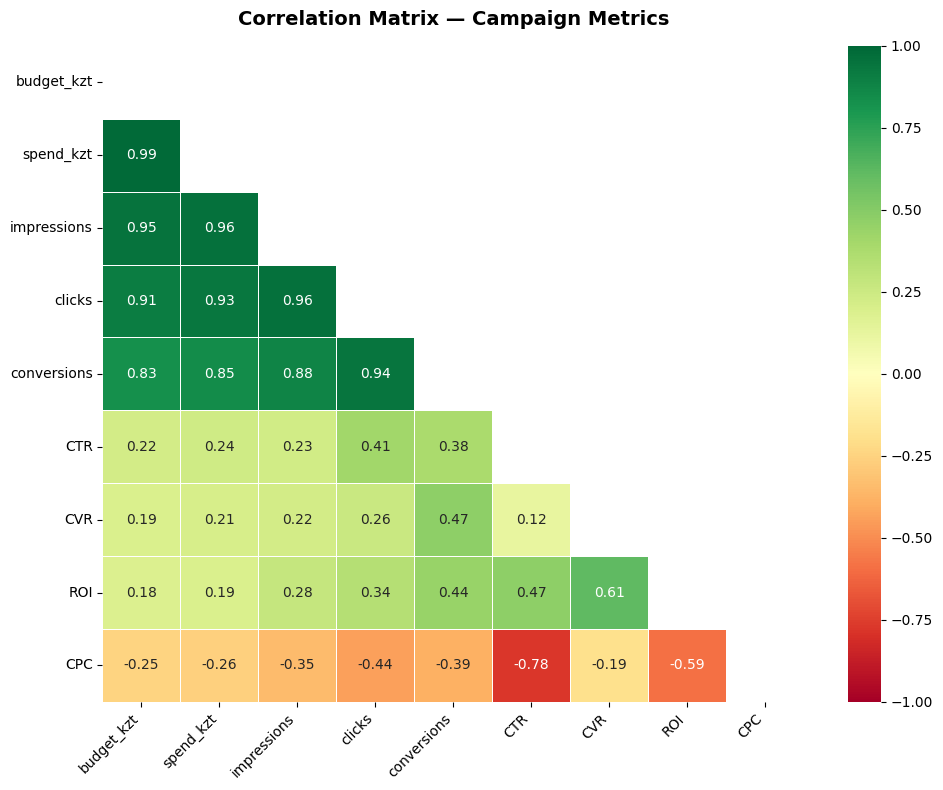

✅ Key insight: Check which metrics strongly correlate with ROI!


In [7]:
# ── BLOCK 7: Correlation Analysis ─────────────────────────
import seaborn as sns

corr_cols = ["budget_kzt", "spend_kzt", "impressions", 
             "clicks", "conversions", "CTR", "CVR", "ROI", "CPC"]

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, 
            annot=True, fmt=".2f",
            cmap="RdYlGn",
            mask=mask,
            linewidths=0.5,
            ax=ax,
            annot_kws={"size": 10},
            vmin=-1, vmax=1)

ax.set_title("Correlation Matrix — Campaign Metrics", 
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Key insight: Check which metrics strongly correlate with ROI!")

=== A/B Test 1: SMM vs Targeted Ads ===
SMM mean ROI:          361%
Targeted Ads mean ROI: 314%
t-statistic: 0.259
p-value:     0.7996
Result: ❌ No significant difference

=== A/B Test 2: Email Marketing vs SEO ===
Email mean ROI: 517%
SEO mean ROI:   391%
t-statistic: 0.582
p-value:     0.5710
Result: ❌ No significant difference


/tmp/ipykernel_638/518121139.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([smm, targeted], labels=["SMM", "Targeted Ads"], patch_artist=True,
/tmp/ipykernel_638/518121139.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([email, seo], labels=["Email Marketing", "SEO"], patch_artist=True,


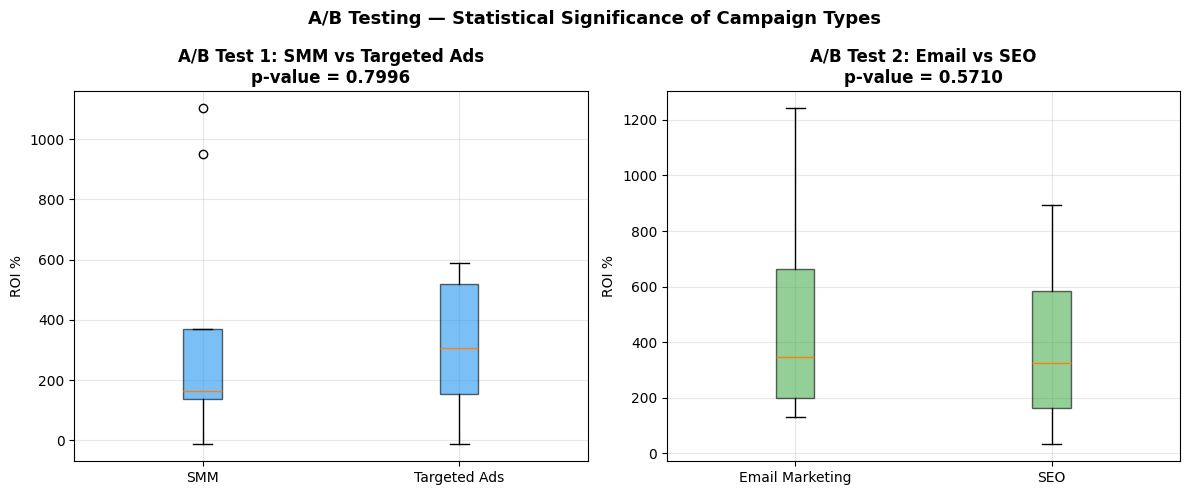

✅ A/B Testing complete!


In [8]:
# ── BLOCK 8: A/B Testing — SMM vs Targeted Ads ────────────
from scipy import stats

smm = df[df["campaign_type"] == "SMM"]["ROI"]
targeted = df[df["campaign_type"] == "Targeted Ads"]["ROI"]
email = df[df["campaign_type"] == "Email Marketing"]["ROI"]
seo = df[df["campaign_type"] == "SEO"]["ROI"]

# T-tests
t1, p1 = stats.ttest_ind(smm, targeted)
t2, p2 = stats.ttest_ind(email, seo)

print("=== A/B Test 1: SMM vs Targeted Ads ===")
print(f"SMM mean ROI:          {smm.mean():,.0f}%")
print(f"Targeted Ads mean ROI: {targeted.mean():,.0f}%")
print(f"t-statistic: {t1:.3f}")
print(f"p-value:     {p1:.4f}")
print(f"Result: {'✅ Significant difference (p < 0.05)' if p1 < 0.05 else '❌ No significant difference'}")

print("\n=== A/B Test 2: Email Marketing vs SEO ===")
print(f"Email mean ROI: {email.mean():,.0f}%")
print(f"SEO mean ROI:   {seo.mean():,.0f}%")
print(f"t-statistic: {t2:.3f}")
print(f"p-value:     {p2:.4f}")
print(f"Result: {'✅ Significant difference (p < 0.05)' if p2 < 0.05 else '❌ No significant difference'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([smm, targeted], labels=["SMM", "Targeted Ads"], patch_artist=True,
                boxprops=dict(facecolor="#2196F3", alpha=0.6))
axes[0].set_title(f"A/B Test 1: SMM vs Targeted Ads\np-value = {p1:.4f}", fontweight="bold")
axes[0].set_ylabel("ROI %")
axes[0].grid(alpha=0.3)

axes[1].boxplot([email, seo], labels=["Email Marketing", "SEO"], patch_artist=True,
                boxprops=dict(facecolor="#4CAF50", alpha=0.6))
axes[1].set_title(f"A/B Test 2: Email vs SEO\np-value = {p2:.4f}", fontweight="bold")
axes[1].set_ylabel("ROI %")
axes[1].grid(alpha=0.3)

plt.suptitle("A/B Testing — Statistical Significance of Campaign Types", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ab_testing.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ A/B Testing complete!")

/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/3902181574.py:49: UserWarning: Glyph 129319 (\N{SNEEZING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) DejaVu Sans.
  plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/3902181574.py:50: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/I

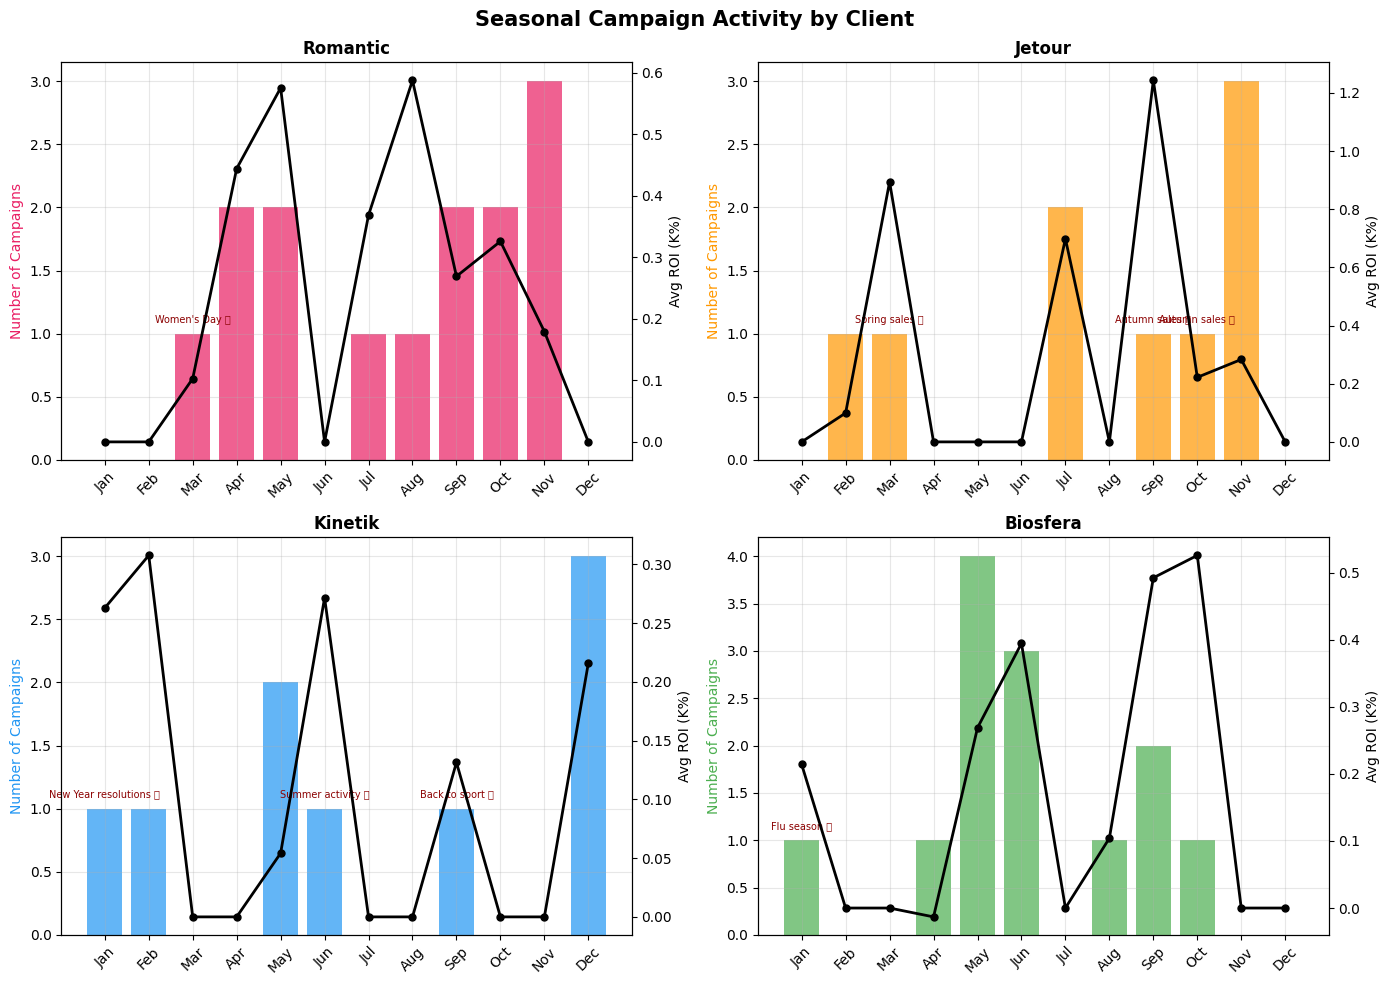

✅ Seasonal analysis complete!


In [9]:
# ── BLOCK 9: Seasonal Analysis ────────────────────────────
df["month"] = df["start_date"].dt.month
df["month_name"] = df["start_date"].dt.strftime("%b")

# Add seasonal context per client
seasonal_events = {
    "Romantic": {2: "Valentine's Day 💝", 3: "Women's Day 🌸", 12: "New Year 🎄"},
    "Jetour":   {3: "Spring sales 🚗", 4: "Spring sales 🚗", 9: "Autumn sales 🍂", 10: "Autumn sales 🍂"},
    "Kinetik":  {1: "New Year resolutions 💪", 6: "Summer activity 🏃", 9: "Back to sport 🏋️"},
    "Biosfera": {1: "Flu season 🤧", 2: "Flu season 🤧", 11: "Cold season 🤧", 12: "Cold season 🤧"},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Seasonal Campaign Activity by Client", fontsize=15, fontweight="bold")
axes = axes.flatten()
client_colors = {"Romantic":"#E91E63","Jetour":"#FF9800","Kinetik":"#2196F3","Biosfera":"#4CAF50"}

for idx, client_name in enumerate(["Romantic", "Jetour", "Kinetik", "Biosfera"]):
    ax = axes[idx]
    client_df = df[df["client_name"] == client_name]
    monthly = client_df.groupby("month").agg(
        campaigns=("campaign_id","count"),
        avg_roi=("ROI","mean"),
        total_spend=("spend_kzt","sum")
    ).reindex(range(1,13), fill_value=0)
    
    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    color = client_colors[client_name]
    
    bars = ax.bar(months, monthly["campaigns"], color=color, alpha=0.7, label="Campaigns")
    ax2 = ax.twinx()
    ax2.plot(months, monthly["avg_roi"]/1000, color="black", 
             linewidth=2, marker="o", markersize=5, label="Avg ROI (K%)")
    
    # Add seasonal event annotations
    events = seasonal_events.get(client_name, {})
    for month_num, event in events.items():
        if monthly.loc[month_num, "campaigns"] > 0:
            ax.annotate(event, xy=(month_num-1, monthly.loc[month_num,"campaigns"]),
                       xytext=(0, 8), textcoords="offset points",
                       ha="center", fontsize=7, color="darkred")
    
    ax.set_title(f"{client_name}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Number of Campaigns", color=color)
    ax2.set_ylabel("Avg ROI (K%)", color="black")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("seasonal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Seasonal analysis complete!")

/tmp/ipykernel_638/1723959675.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/1723959675.py:62: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/1723959675.py:62: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638/1723959675.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("kmeans_clustering.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/1723959675.py:63: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("kmeans_clustering.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_638/1723959675.py:63: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("kmeans_clustering.png", dpi=150, bbox_inches="tight")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


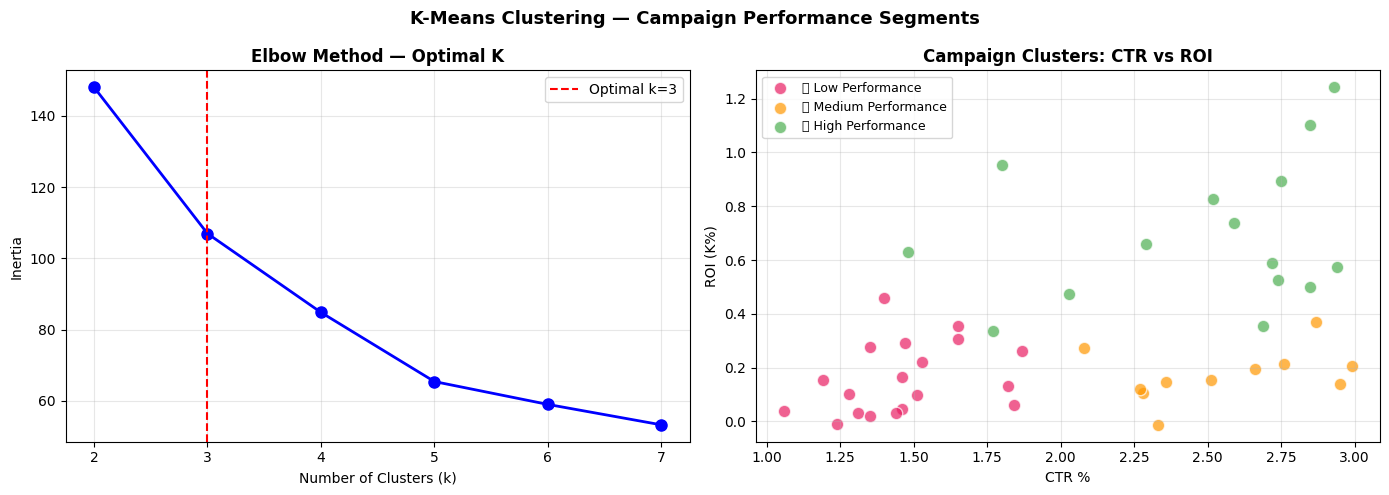

=== Cluster Summary ===

🔴 Low Performance (n=19)
  Avg CTR: 1.47%
  Avg ROI: 160%
  Avg Spend: 141,984 KZT

🟡 Medium Performance (n=11)
  Avg CTR: 2.55%
  Avg ROI: 172%
  Avg Spend: 176,112 KZT

🟢 High Performance (n=15)
  Avg CTR: 2.46%
  Avg ROI: 693%
  Avg Spend: 263,283 KZT


In [10]:
# ── BLOCK 10: K-Means Clustering ──────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features for clustering
features = ["spend_kzt", "CTR", "CVR", "ROI", "CPC"]
X_cluster = df[features].copy()

scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(X_cluster)

# Find optimal k with Elbow method
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled2)
    inertias.append(km.inertia_)

# Apply K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled2)

# FIX: KMeans assigns cluster IDs randomly. Remap them by real avg ROI
# (0 = lowest performance ... 2 = highest) so the labels below are CORRECT.
order = df.groupby("Cluster")["ROI"].mean().sort_values().index
remap = {old: new for new, old in enumerate(order)}
df["Cluster"] = df["Cluster"].map(remap)

cluster_labels = {0: "🔴 Low Performance", 1: "🟡 Medium Performance", 2: "🟢 High Performance"}
cluster_means = df.groupby("Cluster")[features].mean().round(1)
cluster_means["Label"] = cluster_means.index.map(cluster_labels)
cluster_means["Count"] = df.groupby("Cluster").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method — Optimal K", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].axvline(x=3, color="red", linestyle="--", label="Optimal k=3")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cluster scatter
colors_cluster = {0: "#E91E63", 1: "#FF9800", 2: "#4CAF50"}
for cluster in [0, 1, 2]:
    mask = df["Cluster"] == cluster
    axes[1].scatter(df[mask]["CTR"], df[mask]["ROI"]/1000,
                   c=colors_cluster[cluster], label=cluster_labels[cluster],
                   alpha=0.7, s=80, edgecolors="white")

axes[1].set_title("Campaign Clusters: CTR vs ROI", fontweight="bold")
axes[1].set_xlabel("CTR %")
axes[1].set_ylabel("ROI (K%)")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("K-Means Clustering — Campaign Performance Segments", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Cluster Summary ===")
for cluster, label in cluster_labels.items():
    subset = df[df["Cluster"]==cluster]
    print(f"\n{label} (n={len(subset)})")
    print(f"  Avg CTR: {subset['CTR'].mean():.2f}%")
    print(f"  Avg ROI: {subset['ROI'].mean():,.0f}%")
    print(f"  Avg Spend: {subset['spend_kzt'].mean():,.0f} KZT")

=== Linear Regression: Conversion Forecast ===
R² Score:  0.7968  (1.0 = perfect)
MAE:       95 conversions

Feature Coefficients:
  spend_kzt      : -0.000410
  impressions    : +0.001756
  CTR            : +120.077571
  CPC            : +0.915985

=== Future Forecast Scenarios ===
    Scenario  spend_kzt  predicted_conversions
Conservative     100000                   1934
   Base Case     200000                   3769
  Optimistic     400000                   7379


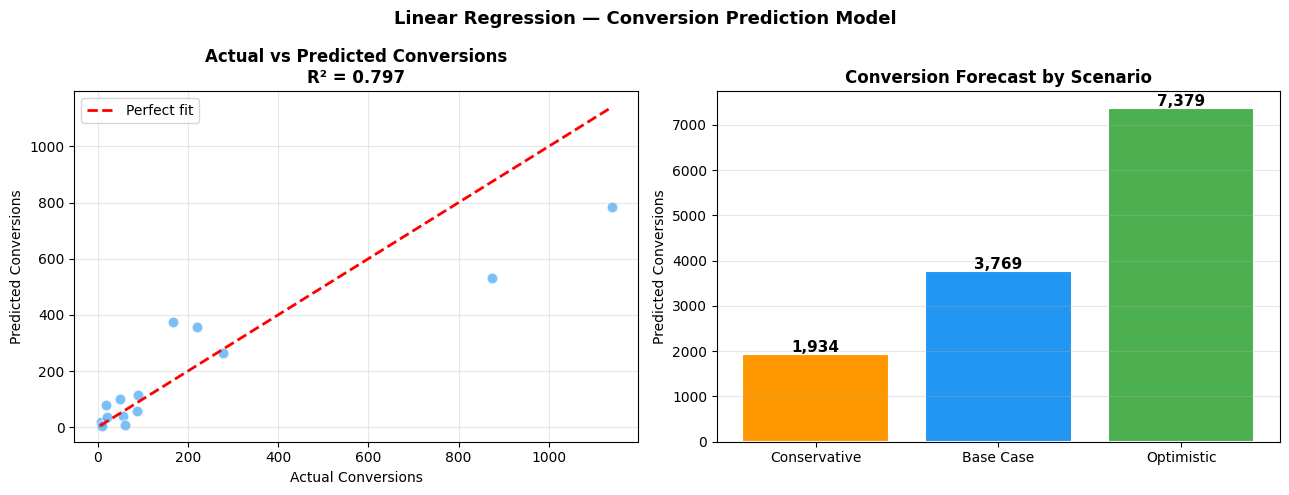

✅ Regression model complete!


In [11]:
# ── BLOCK 11: Conversion Forecast — Linear Regression ─────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Features
from sklearn.model_selection import train_test_split  # FIX: honest evaluation

X_reg = df[["spend_kzt", "impressions", "CTR", "CPC"]].values
y_reg = df["conversions"].values

# FIX: split into train/test so R² reflects unseen data, not memorised data
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=== Linear Regression: Conversion Forecast ===")
print(f"R² Score:  {r2:.4f}  (1.0 = perfect)")
print(f"MAE:       {mae:.0f} conversions")
print("\nFeature Coefficients:")
for feat, coef in zip(["spend_kzt","impressions","CTR","CPC"], reg_model.coef_):
    print(f"  {feat:15s}: {coef:+.6f}")

# Future forecast
future_scenarios = pd.DataFrame({
    "Scenario":    ["Conservative", "Base Case",  "Optimistic"],
    "spend_kzt":   [100_000,         200_000,       400_000],
    "impressions": [1_000_000,       2_000_000,     4_000_000],
    "CTR":         [4.5,             5.5,           7.0],
    "CPC":         [3.0,             2.5,           2.0],
})
future_scenarios["predicted_conversions"] = reg_model.predict(
    future_scenarios[["spend_kzt","impressions","CTR","CPC"]]).astype(int)

print("\n=== Future Forecast Scenarios ===")
print(future_scenarios[["Scenario","spend_kzt","predicted_conversions"]].to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color="#2196F3", edgecolors="white", s=60)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Perfect fit")
axes[0].set_title(f"Actual vs Predicted Conversions\nR² = {r2:.3f}", fontweight="bold")
axes[0].set_xlabel("Actual Conversions")
axes[0].set_ylabel("Predicted Conversions")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Forecast scenarios
colors_s = ["#FF9800", "#2196F3", "#4CAF50"]
bars = axes[1].bar(future_scenarios["Scenario"], 
                   future_scenarios["predicted_conversions"],
                   color=colors_s, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, future_scenarios["predicted_conversions"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f"{val:,}", ha="center", fontweight="bold", fontsize=11)
axes[1].set_title("Conversion Forecast by Scenario", fontweight="bold")
axes[1].set_ylabel("Predicted Conversions")
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Linear Regression — Conversion Prediction Model", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regression_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Regression model complete!")

Average ROI multipliers:
client_name
Biosfera    3.13
Jetour      5.23
Kinetik     1.92
Romantic    3.45
Name: ROI, dtype: float64

=== Optimal Budget Allocation (Total: 10M KZT) ===
  Client  Current_spend  Optimal_budget  Avg_ROI_pct  Expected_revenue  Budget_share_pct
Biosfera        2376365          500000        313.0           2066692               5.0
  Jetour        3838599         5000000        523.0          31136111              50.0
 Kinetik        1649059          500000        192.0           1460500               5.0
Romantic         720147         4000000        345.0          17787714              40.0

Total expected revenue: 52.5M KZT


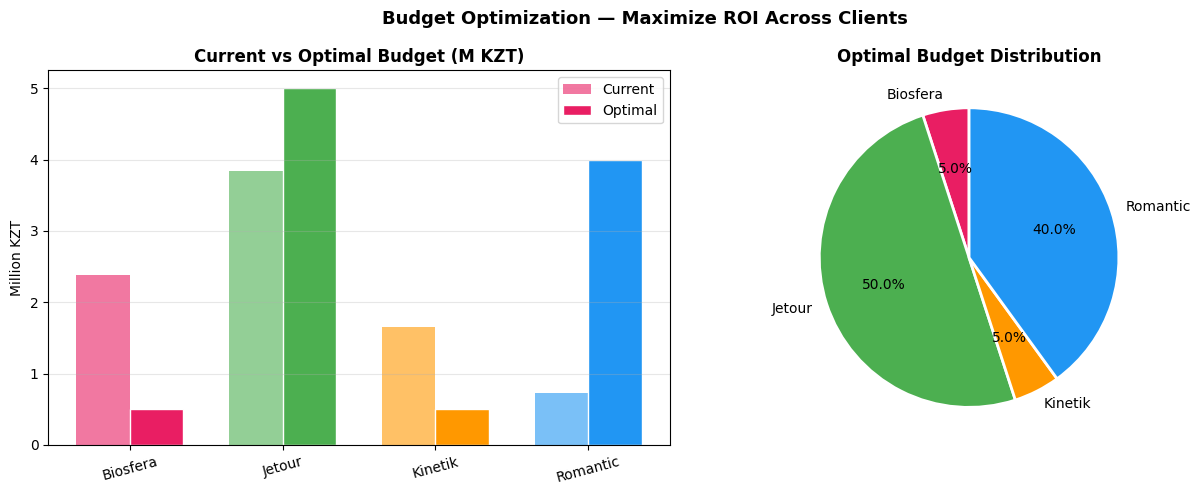

✅ Budget optimization complete!


In [12]:
# ── BLOCK 12: Budget Optimization ─────────────────────────
from scipy.optimize import linprog  # FIX: linear objective -> use a real LP solver

# Average ROI per client (as multiplier)
client_roi = df.groupby("client_name")["ROI"].mean() / 100
print("Average ROI multipliers:")
print(client_roi.round(2))

total_budget = 10_000_000  # 10M KZT
roi_vals = client_roi.values

# FIX: the objective sum(b*(1+roi)) is LINEAR. SLSQP gets stuck at the
# starting point and returns an equal split (not the optimum).
# linprog (HiGHS) solves the linear program correctly.
# maximize sum(b*(1+roi))  ==  minimize -sum((1+roi)*b)
c    = -(1 + roi_vals)
A_eq = [[1] * len(roi_vals)]
b_eq = [total_budget]
bounds_lp = [(500_000, 5_000_000)] * len(roi_vals)   # each client: 0.5M..5M

result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds_lp, method="highs")

optimized = pd.DataFrame({
    "Client":          client_roi.index,
    "Current_spend":   df.groupby("client_name")["spend_kzt"].sum().values,
    "Optimal_budget":  result.x.astype(int),
    "Avg_ROI_pct":     (client_roi.values * 100).round(0),
})
optimized["Expected_revenue"] = (optimized["Optimal_budget"] * 
                                  (1 + client_roi.values)).astype(int)
optimized["Budget_share_pct"] = (optimized["Optimal_budget"] / 
                                  total_budget * 100).round(1)

print("\n=== Optimal Budget Allocation (Total: 10M KZT) ===")
print(optimized.to_string(index=False))
print(f"\nTotal expected revenue: {optimized['Expected_revenue'].sum()/1_000_000:.1f}M KZT")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#E91E63","#4CAF50","#FF9800","#2196F3"]

# Current vs Optimal
x = np.arange(len(optimized))
w = 0.35
axes[0].bar(x-w/2, optimized["Current_spend"]/1_000_000, w,
            label="Current", color=colors, alpha=0.6)
axes[0].bar(x+w/2, optimized["Optimal_budget"]/1_000_000, w,
            label="Optimal", color=colors, alpha=1.0, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(optimized["Client"], rotation=15)
axes[0].set_title("Current vs Optimal Budget (M KZT)", fontweight="bold")
axes[0].set_ylabel("Million KZT")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# Budget share pie
axes[1].pie(optimized["Budget_share_pct"], labels=optimized["Client"],
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Optimal Budget Distribution", fontweight="bold")

plt.suptitle("Budget Optimization — Maximize ROI Across Clients",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("budget_optimization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Budget optimization complete!")

In [13]:
# ── BLOCK 13: Interactive Plotly Dashboard ─────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Spend vs ROI by Client", 
                    "Campaign Type Performance",
                    "Monthly Conversion Trend",
                    "RFM Bubble Chart"),
    specs=[[{"type":"scatter"}, {"type":"bar"}],
           [{"type":"scatter"}, {"type":"scatter"}]]
)

colors_map = {"Romantic":"#E91E63","Jetour":"#FF9800",
              "Kinetik":"#2196F3","Biosfera":"#4CAF50"}

# Chart 1: Spend vs ROI scatter per client
for client in df["client_name"].unique():
    sub = df[df["client_name"]==client]
    fig.add_trace(go.Scatter(
        x=sub["spend_kzt"]/1000, y=sub["ROI"]/1000,
        mode="markers", name=client,
        marker=dict(size=10, color=colors_map[client], opacity=0.7),
        hovertemplate=f"<b>{client}</b><br>Spend: %{{x:.0f}}K KZT<br>ROI: %{{y:.0f}}K%<extra></extra>"
    ), row=1, col=1)

# Chart 2: Avg ROI by campaign type
roi_type = df.groupby("campaign_type")["ROI"].mean().sort_values(ascending=False)/1000
fig.add_trace(go.Bar(
    x=roi_type.index, y=roi_type.values,
    marker_color=["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0","#00BCD4"],
    hovertemplate="<b>%{x}</b><br>Avg ROI: %{y:.0f}K%<extra></extra>",
    showlegend=False
), row=1, col=2)

# Chart 3: Monthly conversions
df["month_period"] = df["start_date"].dt.to_period("M").astype(str)
monthly_conv = df.groupby("month_period")["conversions"].sum().reset_index()
fig.add_trace(go.Scatter(
    x=monthly_conv["month_period"], y=monthly_conv["conversions"],
    mode="lines+markers", line=dict(color="#2196F3", width=2),
    fill="tozeroy", fillcolor="rgba(33,150,243,0.1)",
    hovertemplate="<b>%{x}</b><br>Conversions: %{y:,}<extra></extra>",
    showlegend=False
), row=2, col=1)

# Chart 4: RFM bubble
for _, row_r in rfm.iterrows():
    client = row_r["client_name"]
    fig.add_trace(go.Scatter(
        x=[row_r["Frequency"]], y=[row_r["Monetary_M"]],
        mode="markers+text",
        text=[client], textposition="top center",
        marker=dict(size=row_r["Recency"]/5+20, 
                   color=list(colors_map.values())[list(colors_map.keys()).index(client)],
                   opacity=0.7),
        hovertemplate=f"<b>{client}</b><br>Recency: {row_r['Recency']} days<br>Frequency: {row_r['Frequency']}<br>Monetary: {row_r['Monetary_M']}M KZT<extra></extra>",
        showlegend=False
    ), row=2, col=2)

fig.update_layout(
    title=dict(text="WELON AGENCY — Interactive Analytics Dashboard", 
               font=dict(size=18)),
    height=700, width=1100,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.update_xaxes(title_text="Spend (K KZT)", row=1, col=1)
fig.update_yaxes(title_text="ROI (K%)", row=1, col=1)
fig.update_xaxes(title_text="Campaign Type", row=1, col=2)
fig.update_yaxes(title_text="Avg ROI (K%)", row=1, col=2)
fig.update_xaxes(title_text="Month", row=2, col=1)
fig.update_yaxes(title_text="Conversions", row=2, col=1)
fig.update_xaxes(title_text="Frequency", row=2, col=2)
fig.update_yaxes(title_text="Monetary (M KZT)", row=2, col=2)

fig.write_html("welon_interactive_dashboard.html")
fig.show()
print("✅ Interactive dashboard saved as welon_interactive_dashboard.html")

✅ Interactive dashboard saved as welon_interactive_dashboard.html


In [14]:
# ── BLOCK 14: Feature Engineering ─────────────────────────
import pandas as pd
import numpy as np
from datetime import timedelta

np.random.seed(42)

clients = pd.DataFrame([
    {"client_id": 1, "name": "Romantic",  "industry": "Retail / Flowers",     "city": "Almaty",  "contract_start": "2023-03-01"},
    {"client_id": 2, "name": "Biosfera",  "industry": "Healthcare / Pharmacy", "city": "Almaty",  "contract_start": "2023-01-15"},
    {"client_id": 3, "name": "Jetour",    "industry": "Automotive",            "city": "Almaty",  "contract_start": "2023-06-10"},
    {"client_id": 4, "name": "Kinetik",   "industry": "Healthcare / Sports",   "city": "Astana",  "contract_start": "2023-09-01"},
])
clients["contract_start"] = pd.to_datetime(clients["contract_start"])

campaign_types = ["SMM", "Targeted Ads", "SEO", "Content Marketing", "Email Marketing", "Influencer"]

rows = []
cid = 1
for _, client in clients.iterrows():
    for i in range(np.random.randint(8, 16)):
        start = client["contract_start"] + timedelta(days=np.random.randint(0, 300))
        end   = start + timedelta(days=np.random.randint(14, 60))
        budget_ranges = {
            "Romantic": [30000, 50000, 80000, 100000],
            "Biosfera": [80000, 120000, 200000, 350000],
            "Kinetik":  [100000, 150000, 200000, 300000],
            "Jetour":   [200000, 350000, 500000, 800000],
        }
        budget = np.random.choice(budget_ranges[client["name"]])
        spend  = round(budget * np.random.uniform(0.75, 1.0))
        impressions = int(spend * np.random.uniform(0.4, 1.0))       # CPM ~1000-2500 KZT
        clicks      = int(impressions * np.random.uniform(0.01, 0.03)) # CTR ~1-3%
        conversions = int(clicks * np.random.uniform(0.02, 0.08))      # CVR ~2-8%
        revenue     = round(conversions * np.random.uniform(3000, 10000)) # realistic ROAS
        rows.append({
            "campaign_id": cid, "client_id": client["client_id"],
            "client_name": client["name"],
            "campaign_type": np.random.choice(campaign_types),
            "start_date": start, "end_date": end,
            "budget_kzt": budget, "spend_kzt": spend,
            "impressions": impressions, "clicks": clicks,
            "conversions": conversions, "revenue_kzt": revenue,
        })
        cid += 1

df = pd.DataFrame(rows)
df["CTR"] = (df["clicks"] / df["impressions"] * 100).round(2)
df["CVR"] = (df["conversions"] / df["clicks"].replace(0,1) * 100).round(2)
df["ROI"] = ((df["revenue_kzt"] - df["spend_kzt"]) / df["spend_kzt"] * 100).round(1)
df["CPC"] = (df["spend_kzt"] / df["clicks"].replace(0,1)).round(0)

# New features
df["campaign_duration_days"]    = (df["end_date"] - df["start_date"]).dt.days
df["spend_per_day"]             = (df["spend_kzt"] / df["campaign_duration_days"]).round(0)
df["budget_utilization"]        = (df["spend_kzt"] / df["budget_kzt"] * 100).round(1)
df["revenue_per_click"]         = (df["revenue_kzt"] / df["clicks"].replace(0,1)).round(0)
df["cost_per_conversion"]       = (df["spend_kzt"] / df["conversions"].replace(0,1)).round(0)
df["impression_to_conversion"]  = (df["conversions"] / df["impressions"] * 100).round(4)
df["start_month"]               = df["start_date"].dt.month
df["start_quarter"]             = df["start_date"].dt.quarter
df["is_high_season"]            = df["start_month"].isin([2,3,9,10,11,12]).astype(int)

print("=== New Features Created ===")
new_features = [
    "campaign_duration_days", "spend_per_day", "budget_utilization",
    "revenue_per_click", "cost_per_conversion",
    "impression_to_conversion", "start_month",
    "start_quarter", "is_high_season"
]
print(df[new_features].describe().round(2))
print(f"\n✅ Total features: {len(df.columns)} columns")

=== New Features Created ===
       campaign_duration_days  spend_per_day  budget_utilization  \
count                   45.00          45.00               45.00   
mean                    37.89        6899.02               86.56   
std                     15.33        8652.21                7.72   
min                     14.00         433.00               75.20   
25%                     21.00        1607.00               79.40   
50%                     42.00        3527.00               85.90   
75%                     52.00        7616.00               92.60   
max                     59.00       42159.00               99.90   

       revenue_per_click  cost_per_conversion  impression_to_conversion  \
count              45.00                45.00                     45.00   
mean              309.22              2056.38                      0.11   
std               149.41              1401.34                      0.05   
min                81.00               640.00             